<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Astrofisica-moderna/proyecto_comp3_astromod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analisis datos survey 21 cm line**

Datos de la temperatura de brillo de la linea 21 cm HI en funcion de la velocidad de corrimiento y la longitud galactica
<br><br>

#### **Astrofisica moderna:** Proyecto computacional 3
##### Prof. German Chaparro Molano

> Juan Manuel Cardenas
<br>

Instalacion e importe de librerias

In [ ]:
!pip install -q lmfit

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from lmfit.models import GaussianModel
%matplotlib inline

plt.style.use('seaborn-v0_8-dark-palette')

### **A) Segun lo visto en clase, demuestre la expresion:**

(1 pt) Demostrar, usando $|v|=|v_⊙|$


$$ R = R_o \frac{v_⊙ \sin l }{ v_{LOS} + v_⊙ \sin l} $$


Para relacionar las cantidades deseadas, se usa trigonometria. Formando un triangulo con aristas (Sol, centro galactico CG, otro punto arbitrario en la galaxia). Se define el angulo $α$ (angulo entre el vector velocidad del sol y la linea de vision (LOS), que se relaciona con la longitud galactica mediante $α = l - 90°$), y el angulo $β$ (angulo entre el vector radio galactico $R$ del objeto arbitrario y la linea (LOS))


<img src=https://i.postimg.cc/tTpjvMkW/Whats-App-Image-2024-08-14-at-1-39-20-PM.jpg width="500">


Se tienen los parametros del sistema formando un triangulo:

* $R_☉$ es la distancia del Sol al centro galáctico (GC)
* $v_☉$ es la velocidad del sol alrededor de la galaxia   
* $v$ la velocidad de un objeto cualquiera en la galaxia
* $v_{LOS}$ es la velocidad relativa del sol respecto al objeto deseado
* $l$ longitud galactica del objeto deseado (angulo entre el radio galactico del sol y la linea (LOS) entre le objeto y el sol)


Con condicion $|v|=|v_☉|$ por la curva de rotacion plana y asumiendo que los puntos se mumeven en orbitas circulares, perpendiculares al vector de radio al centro galactico de cada punto.





la velocidad relativa es la resta galileana entre las componentes de las velocidades sobre la linea (LOS)


$$ v_{\text{LOS}} = v \sin(\beta) - v_☉ \cos(α) $$

$$ \sin(\beta) = \frac{v_{\text{LOS}}+v_☉cos(α)}{v} $$



Por la ley de Seno del triangulo de la figura, se puede obtener el valor del radio galactico del objeto deseado:

$$ \frac{\sin(l)}{R}=\frac{\sin(\beta)}{R_☉} $$

$$ R = R_☉ \frac{\sin(l)}{\sin(\beta)} $$


Reemplazando $\sin(\beta)$ previo en $R$  


$$ R = R_☉ \frac{v\sin(l)}{v_{LOS}+v_☉cos(α)} $$
$$ R = R_☉ \frac{v\sin(l)}{v_{LOS}+v_☉\sin(l)} $$


Finalmente empleando **$|v|=|v_☉|$**

$$R = R_☉ \frac{v_☉\sin(l)}{v_{LOS}+v_☉ \sin(l)} $$


<br><br>

___

Montaje de datos desde drive, si los datos los sube a mano al notebook el path es nulo.

In [ ]:
from google.colab import drive
drive.mount('/content/drive') # monta drive
path = '/content/drive/MyDrive/Colab Notebooks/'
# drive.flush_and_unmount() # desmonta drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Carga de los archivos**

In [ ]:
a = np.loadtxt(path + '21cmsurvey_full.txt') # [long, k] # vel.shape, a.shape
vel = np.loadtxt(path + 'vel.txt')/1000      # v_LOS [km/s]

**Separacion de los datos:** <br>
longitud galactica y temperatura de brillo

In [ ]:
# galactic longitude [deg]
longi = a[0]

# spectra in Tb: brightness temperature [K]
spgr = a[1:]

### **Temperatura de brillo en funcion de: la velocidad (a lo largo de la linea de vision) y la longitud galactica.**

Las observaciones se realizaron mirando hacia afuera de la galaxia como lo muestra el rango de la longitud galactica alejado de $0°$

<img src=https://i.postimg.cc/hjPhn81W/Gal-Long-Lat-of-Star.jpg width="400">


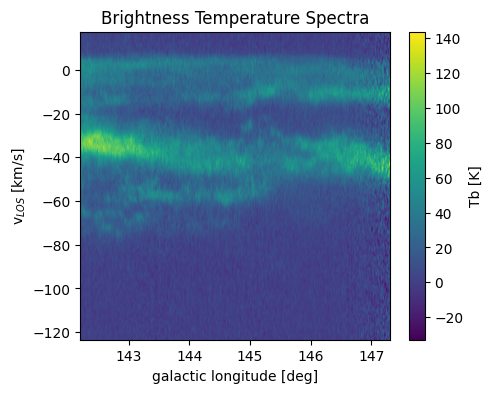

In [ ]:
plt.figure(figsize=(5,4))
img = plt.imshow(spgr, extent=[longi[-1],longi[0],vel[-1],vel[0]], aspect='auto')
plt.title('Brightness Temperature Spectra')
plt.xlabel('galactic longitude [deg]')
plt.ylabel('v$_{LOS}$ [km/s]')
cbar = plt.colorbar(img)
cbar.set_label('Tb [K]')
plt.show()

Se observa que hay regiones que se alejan o acerca mas rapido que otras

### **B ) Ajuste gaussiano para pico principal:** brazo de Perseo

(1.5 pt) Ajuste una funcion gaussiana para el pico principal (correspondiente a la emisi ́on de gas en el brazo de Perseo) para **cada una de las longitudes**, considerando unicamente las velocidades comprendidas entre $-15$ y $-50$ [km/s] Haga $3$ graficas (correspondientes al valor mınimo, medio, y maximo de longitud galactica) que muestren que su ajuste de los espectros a funciones gaussianas es razonable.


In [ ]:
# parametros fijos
x = vel       # velocidad

para el modelo gaussiano se usaron los dos metodos del notebook de github del profesor para este punto, para el del brazo externo ya solo se uso el metodo 2 por simplificar el codigo.

In [ ]:
# Metodo 1
sigma_m1 = 6

def gauss(x, *p):
    A, mu, sigma = p
    return A*np.exp(-(x-mu)**2/(2.*sigma**2))

In [ ]:
# Metodo 2

# Crea modelo gaussiano y parametros
gauss1 = GaussianModel(prefix='g1_')
pars = gauss1.make_params()

# Establece rango de parametros
x_max = -15
x_min = -50
x_mean = -30
pars['g1_center'].set(value=x_mean, min=x_min, max=x_max)
pars['g1_sigma'].set(value=2, min=1, max=10)
pars['g1_amplitude'].set(value=1000, min=20, max=3000)

# Modelo
mod = gauss1

In [ ]:
# guardar los datos
metod1 = []
metod2 = []
Y = []
Xcenter = []
sigmas  = []

for i in tqdm(range(len(longi))): # cada longitud
  y = spgr[:,i] # temperatura

  # Metodo 1
  g1 = gauss(x, y.max(), x[np.argmax(y)], sigma_m1) # evaluando datos

  # Metodo 2
  out = mod.fit(y, pars, x=x) # modelo
  comps = out.eval_components(x=x) # evaluación del modelo

  # guardando datos
  metod1.append(g1)
  metod2.append(comps['g1_'])
  Y.append(y)
  Xcenter.append(out.params['g1_center'].value)
  sigmas.append(out.params['g1_sigma'].value)

100%|██████████| 1024/1024 [00:40<00:00, 25.21it/s]


grafica de las 3 longitudes galacticas

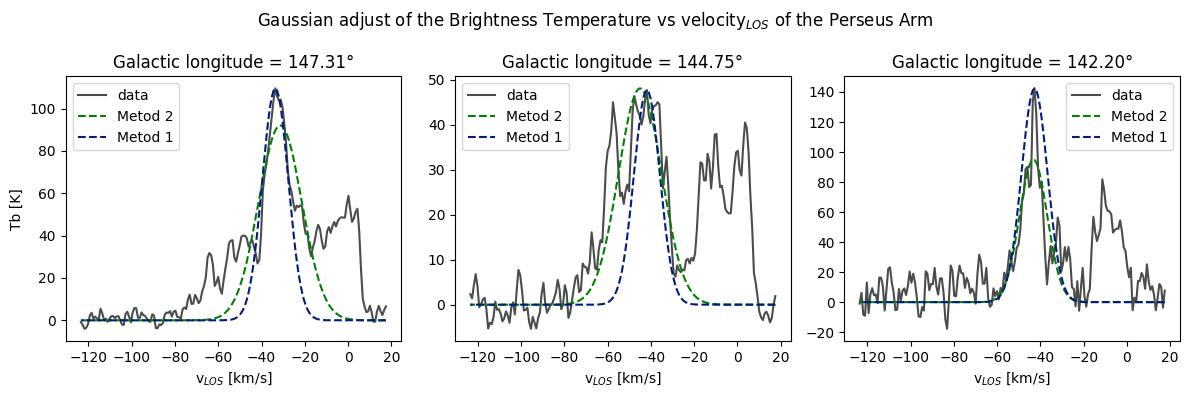

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(12,4))
fig.suptitle('Gaussian adjust of the Brightness Temperature vs velocity$_{LOS}$ of the Perseus Arm')

ax[0].set_title(f'Galactic longitude = {longi[0]:.2f}°')
ax[0].plot(x, Y[0], 'k', label='data', alpha=0.7)
ax[0].plot(x, metod2[0], 'g--', label='Metod 2')
ax[0].plot(x, metod1[0], '--', label='Metod 1')
ax[0].set_xlabel('v$_{LOS}$ [km/s]')
ax[0].set_ylabel('Tb [K]')

med = int(len(longi)/2)
ax[1].set_title(f'Galactic longitude = {longi[med]:.2f}°')
ax[1].plot(x, Y[med], 'k', label='data', alpha=0.7)
ax[1].plot(x, metod2[med], 'g--', label='Metod 2')
ax[1].plot(x, metod1[med], '--', label='Metod 1')
ax[1].set_xlabel('v$_{LOS}$ [km/s]')

ax[2].set_title(f'Galactic longitude = {longi[-1]:.2f}°')
ax[2].plot(x, Y[-1], 'k', label='data', alpha=0.7)
ax[2].plot(x, metod2[-1], 'g--', label='Metod 2')
ax[2].plot(x, metod1[-1], '--', label='Metod 1')
ax[2].set_xlabel('v$_{LOS}$ [km/s]')

ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.tight_layout()
plt.show()

In [ ]:
# reporte del ajuste
# print(out.fit_report(min_correl=0.5))

### **C) Longitud galactica $l$ en funcion del radio galactico $R$**

(1.5 pt) Usando el centro **(valor medio)** de cada gaussiana, haga una grafica de longitud galactica $l$ vs $R$ (radio respecto al centro de la galaxia) para el brazo de Perseo.
<br>

Incluya un intervalo de confianza (2σ) para $R$ para cada longitud a partir de la varianza de cada gaussiana.

**Formula de distancia al centro**

$$ R = R_o \frac{v_⊙ \sin l }{ v_{LOS} + v_⊙ \sin l} $$

Usando $R_☉ = 8.4$ Kpc y $v_☉=225$ km/s

In [ ]:
Ro = 8.4    # [kpc]
v_sun = 225 # [km/s]
lon = longi*np.pi/180 # [rad]

# Distancia al centro galactico
R = Ro * v_sun*np.sin(lon) / ( Xcenter + v_sun*np.sin(lon) ) # [kpc]

# intervalo de 2 sigmas
Xcenter_up = np.array(Xcenter) + sigmas
Xcenter_down = np.array(Xcenter) - sigmas
R_max = Ro * v_sun*np.sin(lon) / ( Xcenter_up + v_sun*np.sin(lon) ) # [kpc]
R_min = Ro * v_sun*np.sin(lon) / ( Xcenter_down + v_sun*np.sin(lon) ) # [kpc]

grafica de Longitud Galactica en funcion del Radio Galactico

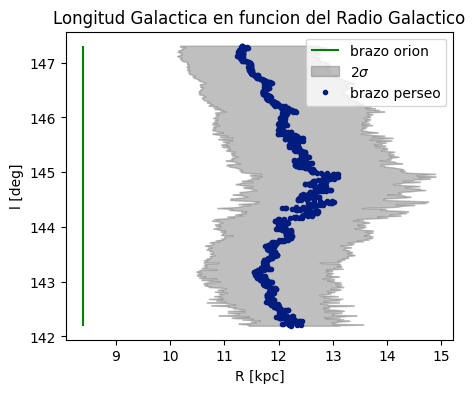

In [ ]:
plt.figure(figsize=(5,4))
plt.title('Longitud Galactica en funcion del Radio Galactico')
plt.vlines(Ro, longi[0],longi[-1], 'g',label='brazo orion')
plt.fill_betweenx(longi, R_min, R_max, color='gray', alpha=0.5, label='2$σ$')
plt.plot(R, longi, '.', label='brazo perseo')
plt.ylabel('l [deg]')
plt.xlabel('R [kpc]')
plt.legend()
plt.show()

___

### **D) Repeticion de para el brazo externo**

Repita los dos puntos anteriores para el brazo externo, identificando el rango adecuado de velocIdades. (1 pt)

Dado que el brazo externo se encuentra mas lejos que el de perseo, se tomara el rango de velocidades de -50 a -80 km/s

In [ ]:
# Metodo 2
# Crea modelo gaussiano y parametros
gauss1 = GaussianModel(prefix='g1_')
pars = gauss1.make_params()

# Establece rango de parametros
x_max = -50
x_min = -80
x_mean = -60
pars['g1_center'].set(value=x_mean, min=x_min, max=x_max)
pars['g1_sigma'].set(value=2, min=1, max=10)
pars['g1_amplitude'].set(value=1000, min=20, max=3000)

# Modelo
mod = gauss1

In [ ]:
# guardar los datos
metod1 = []
metod2 = []
Y = []
Xcenter = []
sigmas  = []

for i in tqdm(range(len(longi))):
  y = spgr[:,i] # temperatura

  # Metodo 2
  out = mod.fit(y, pars, x=x) # modelo
  comps = out.eval_components(x=x) # evaluación del modelo

  # guardando datos
  metod1.append(g1)
  metod2.append(comps['g1_'])
  Y.append(y)
  Xcenter.append(out.params['g1_center'].value)
  sigmas.append(out.params['g1_sigma'].value)

100%|██████████| 1024/1024 [00:25<00:00, 40.57it/s]


grafica de las 3 longitudes galacticas

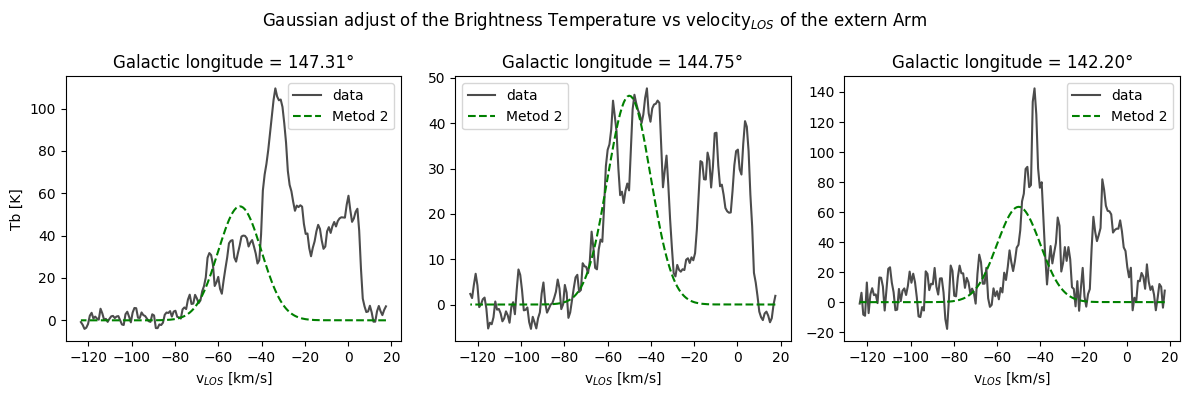

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(12,4))
fig.suptitle('Gaussian adjust of the Brightness Temperature vs velocity$_{LOS}$ of the extern Arm')

ax[0].set_title(f'Galactic longitude = {longi[0]:.2f}°')
ax[0].plot(x, Y[0], 'k', label='data', alpha=0.7)
ax[0].plot(x, metod2[0], 'g--', label='Metod 2')
ax[0].set_xlabel('v$_{LOS}$ [km/s]')
ax[0].set_ylabel('Tb [K]')

med = int(len(longi)/2)
ax[1].set_title(f'Galactic longitude = {longi[med]:.2f}°')
ax[1].plot(x, Y[med], 'k', label='data', alpha=0.7)
ax[1].plot(x, metod2[med], 'g--', label='Metod 2')
ax[1].set_xlabel('v$_{LOS}$ [km/s]')

ax[2].set_title(f'Galactic longitude = {longi[-1]:.2f}°')
ax[2].plot(x, Y[-1], 'k', label='data', alpha=0.7)
ax[2].plot(x, metod2[-1], 'g--', label='Metod 2')
ax[2].set_xlabel('v$_{LOS}$ [km/s]')

ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.tight_layout()
plt.show()

**Formula de distancia al centro**

$$ R = R_o \frac{v_⊙ \sin l }{ v_{LOS} + v_⊙ \sin l} $$

Usando $R_☉ = 8.4$ Kpc y $v_☉=225$ km/s

In [ ]:
Ro = 8.4    # [kpc]
v_sun = 225 # [km/s]
lon = longi*np.pi/180 # [rad]

# Distancia al centro galactico
R = Ro * v_sun*np.sin(lon) / ( Xcenter + v_sun*np.sin(lon) ) # [kpc]

# intervalo de 2 sigmas
Xcenter_up = np.array(Xcenter) + sigmas
Xcenter_down = np.array(Xcenter) - sigmas
R_max = Ro * v_sun*np.sin(lon) / ( Xcenter_up + v_sun*np.sin(lon) ) # [kpc]
R_min = Ro * v_sun*np.sin(lon) / ( Xcenter_down + v_sun*np.sin(lon) ) # [kpc]

grafica de Longitud Galactica en funcion del Radio Galactico

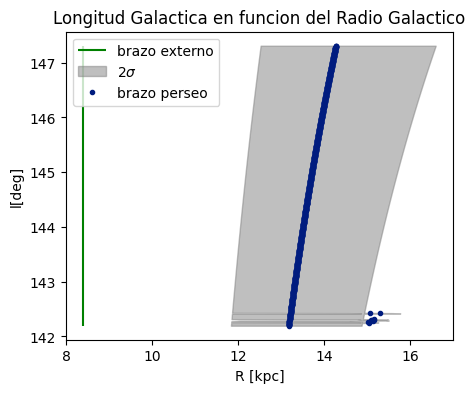

In [ ]:
plt.figure(figsize=(5,4))
plt.title('Longitud Galactica en funcion del Radio Galactico')
plt.vlines(Ro, longi[0],longi[-1], 'g',label='brazo externo')
plt.fill_betweenx(longi, R_min, R_max, color='gray', alpha=0.5, label='2$σ$')
plt.plot(R, longi, '.', label='brazo perseo')
plt.ylabel('l[deg]')
plt.xlabel('R [kpc]')
plt.legend()
plt.show()